<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/mashroom_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA ( exploratory data analysis )

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
# logisticRegression problem
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# implement confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import joblib
# implement support vector algo
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_csv("mushrooms.csv")
df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [ ]:
df.duplicated().sum()

np.int64(0)

# Feature Association & Selection

Top 5 Most Related Features:
odor                        0.628043
spore-print-color           0.333199
gill-color                  0.289027
ring-type                   0.220436
stalk-surface-above-ring    0.197357
Name: MI Scores, dtype: float64


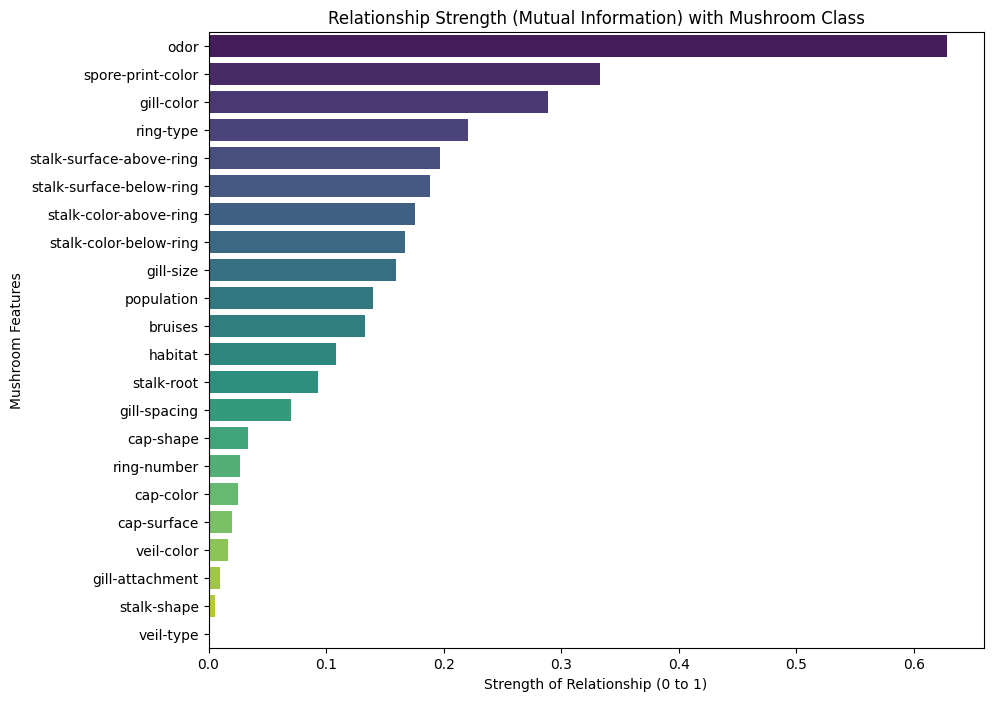

In [ ]:
# 1. Load data

# 2. Encode categorical data to numbers for the math engine
df_encoded = df.apply(LabelEncoder().fit_transform)

X = df_encoded.drop('class', axis=1) # Features
y = df_encoded['class']              # Target

# 3. Calculate Mutual Information (Relationship Strength)
# discrete_features=True because our data is categorical
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_results = pd.Series(mi_scores, name="MI Scores", index=X.columns).sort_values(ascending=False)

# 4. Visualize the results
plt.figure(figsize=(10, 8))
sns.barplot(x=mi_results.values, y=mi_results.index, hue=mi_results.index, palette='viridis', legend=False)
plt.title("Relationship Strength (Mutual Information) with Mushroom Class")
plt.xlabel("Strength of Relationship (0 to 1)")
plt.ylabel("Mushroom Features")
plt.savefig('feature_importance.png')

# 5. Print top features
print("Top 5 Most Related Features:")
print(mi_results.head(5))

In [ ]:
mi_results

,MI Scores
odor,0.628043
spore-print-color,0.333199
gill-color,0.289027
ring-type,0.220436
stalk-surface-above-ring,0.197357
stalk-surface-below-ring,0.188463
stalk-color-above-ring,0.175952
stalk-color-below-ring,0.167337
gill-size,0.159531
population,0.139987


# Advanced Data Visualization (Correlation Analysis)

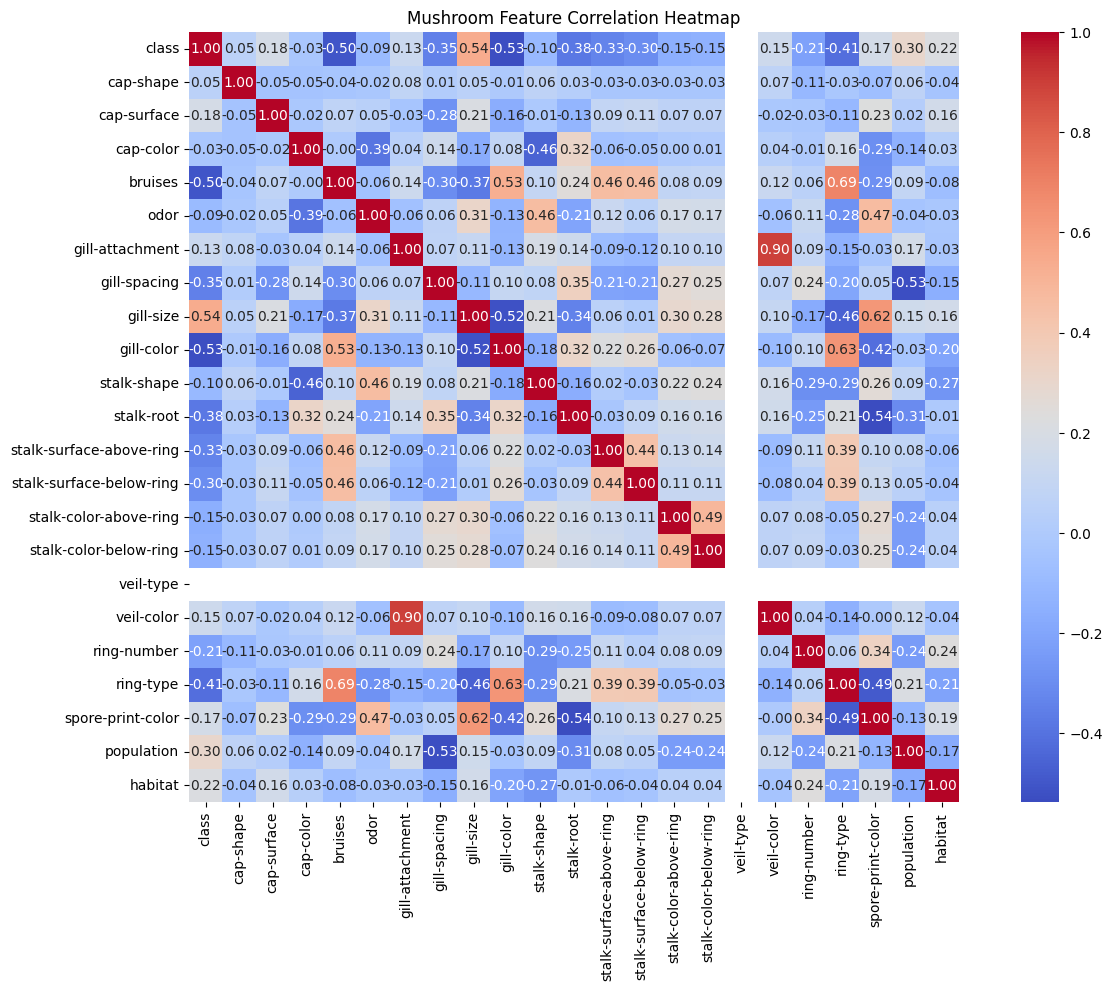

In [ ]:
# Load the dataset

# 1. Transform categorical text into numbers so we can do math
# This is necessary because correlation formulas require numerical input
df_encoded = df.apply(LabelEncoder().fit_transform)

# 2. Calculate the correlation matrix
# This compares every column against every other column
corr_matrix = df_encoded.corr()

# 3. Create the Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Mushroom Feature Correlation Heatmap")
plt.savefig('correlation_heatmap.png')

# Data preprocessing

In [ ]:
selected_features = ['odor', 'spore-print-color', 'gill-color', 'ring-type', 'stalk-surface-above-ring']
# here we are using 2 or 3 perticular column that use in past
# selected_features= ['spore-print-color', 'gill-color']
target = 'class'

In [ ]:
# Create a new dataframe with only your chosen columns
df_subset = df[selected_features + [target]].copy()

In [ ]:
le = LabelEncoder()
df_subset['class'] = le.fit_transform(df_subset['class'])

In [ ]:
# 3. One-Hot Encode the Features
# This creates separate 0/1 columns for each smell, color, etc.
df_final_new = pd.get_dummies(df_subset, columns=selected_features, dtype=int)

In [ ]:
print("New Dataset Shape:", df_final_new.shape)
print("\nFirst 5 rows of the transformed data:")
print(df_final_new.head())

New Dataset Shape: (8124, 40)

First 5 rows of the transformed data:
   class  odor_a  odor_c  odor_f  odor_l  odor_m  odor_n  odor_p  odor_s  \
0      1       0       0       0       0       0       0       1       0   
1      0       1       0       0       0       0       0       0       0   
2      0       0       0       0       1       0       0       0       0   
3      1       0       0       0       0       0       0       1       0   
4      0       0       0       0       0       0       1       0       0   

   odor_y  ...  gill-color_y  ring-type_e  ring-type_f  ring-type_l  \
0       0  ...             0            0            0            0   
1       0  ...             0            0            0            0   
2       0  ...             0            0            0            0   
3       0  ...             0            0            0            0   
4       0  ...             0            1            0            0   

   ring-type_n  ring-type_p  stalk-surface-abov

# Train split data

In [ ]:
# X = df_final.drop('class', axis=1)
# y = df_final['class']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X = df_final_new.drop('class', axis=1)
y = df_final_new['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# print(f"Total mushrooms: {len(df_final)}")
# print(f"Training set size: {len(X_train)} (Questions for the model)")
# print(f"Testing set size: {len(X_test)} (The Surprise Quiz)")


print(f"Total mushrooms: {len(df_final_new)}")
print(f"Training set size: {len(X_train)} (Questions for the model)")
print(f"Testing set size: {len(X_test)} (The Surprise Quiz)")

Total mushrooms: 8124
Training set size: 6499 (Questions for the model)
Testing set size: 1625 (The Surprise Quiz)


# Logistic regression problem

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:

y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.94%


# knn algorithm

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
pridt_knn = model_knn.predict(X_test)
accuracy = accuracy_score(y_test, pridt_knn)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.94%


# naive bayes algorithm

In [ ]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
predt_nv = model_nb.predict(X_test)
accuracy = accuracy_score(y_test, predt_nv)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.32%


# dicision tree

In [ ]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
predt_dt = model_dt.predict(X_test)
accuracy = accuracy_score(y_test, predt_dt)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.94%


In [ ]:
joblib.dump(X.columns.tolist(), "mushroom_columns.joblib")

['mushroom_columns.joblib']

In [ ]:
joblib.dump(model_dt, "mushroom_model.joblib")

['mushroom_model.joblib']

# checking for overfitting

In [ ]:
# pending

# confusion matrix phase

In [ ]:
cm = confusion_matrix(y_test, y_pred)

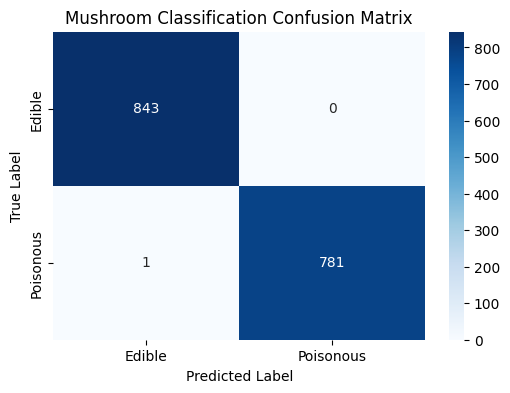

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Mushroom Classification Confusion Matrix')
plt.show()

In [ ]:
print("\n--- Detailed Performance Report ---")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))


--- Detailed Performance Report ---
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       843
   Poisonous       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# trying with take other features ( columns )

In [ ]:

new_features = ['gill-size', 'population', 'bruises', 'habitat', 'stalk-root']

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [ ]:
X_new = pd.get_dummies(df[new_features], dtype=int)
y = df['class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)
new_model = LogisticRegression(random_state=42)
new_model.fit(X_train, y_train)
y_pred = new_model.predict(X_test)
new_accuracy = accuracy_score(y_test, y_pred)

In [ ]:
print(f"New Feature Set Accuracy: {new_accuracy * 100:.2f}%")

New Feature Set Accuracy: 92.68%


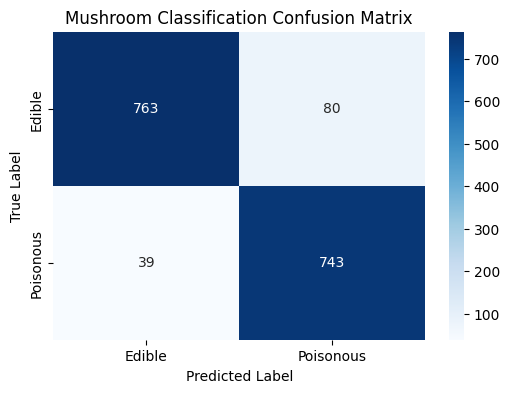

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Mushroom Classification Confusion Matrix')
plt.show()

In [ ]:
print("\n--- Detailed Performance Report ---")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))


--- Detailed Performance Report ---
              precision    recall  f1-score   support

      Edible       0.95      0.91      0.93       843
   Poisonous       0.90      0.95      0.93       782

    accuracy                           0.93      1625
   macro avg       0.93      0.93      0.93      1625
weighted avg       0.93      0.93      0.93      1625



# SUPPORT VECTOR MACHINE ( SVM )

In [ ]:
best_features_svm = ['odor', 'spore-print-color', 'gill-color', 'ring-type', 'stalk-surface-above-ring']

In [ ]:
# Encode Target with a unique variable name
le_svm = LabelEncoder()
y_svm = le_svm.fit_transform(df['class'])

In [ ]:
# One-Hot Encode Features with a unique variable name
X_encoded_svm = pd.get_dummies(df[best_features_svm], dtype=int)

In [ ]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_encoded_svm, y_svm, test_size=0.2, random_state=42
)

In [ ]:
# Initialize SVM with a unique model name
svm_model_final = SVC(kernel='linear', random_state=42)

In [ ]:
svm_model_final.fit(X_train_svm, y_train_svm)
y_pred_svm_final = svm_model_final.predict(X_test_svm)

In [ ]:
# Calculate Accuracy
final_svm_acc = accuracy_score(y_test_svm, y_pred_svm_final)
print(f"SVM Accuracy with Top Features: {final_svm_acc * 100:.2f}%")

SVM Accuracy with Top Features: 99.94%


In [ ]:
# compare actual value with predicted value
results_df_svm = pd.DataFrame({'Actual': y_test_svm, 'Predicted': y_pred_svm_final})
display(results_df_svm.head(20))

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
7,1,1
8,0,0
9,0,0


# confusion matrix for svm

In [ ]:
cm_svm = confusion_matrix(y_test_svm, y_pred_svm_final)

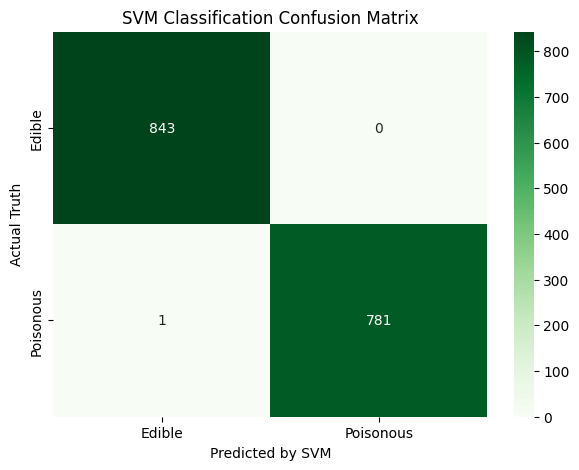

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted by SVM')
plt.ylabel('Actual Truth')
plt.title('SVM Classification Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test_svm, y_pred_svm_final,
                            target_names=['Edible', 'Poisonous']))

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       843
   Poisonous       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# trying it with other features

In [ ]:
new_features_svm = ['gill-size', 'population', 'bruises', 'habitat', 'stalk-root']

In [ ]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [ ]:
X_feature_new_svm = pd.get_dummies(df[new_features_svm], dtype=int)
y_new_svm = df['class']

In [ ]:
X_train_new_svm, X_test_new_svm, y_train_new_svm, y_test_new_svm = train_test_split(
    X_feature_new_svm, y_svm, test_size=0.2, random_state=42
)

In [ ]:
svm_new_model_final = SVC(kernel='linear', random_state=42)

In [ ]:
svm_new_model_final.fit(X_train_new_svm, y_train_new_svm)
y_pred_new_svm_final = svm_new_model_final.predict(X_test_new_svm)

In [ ]:
# Calculate Accuracy
final_svm_acc_new = accuracy_score(y_test_new_svm, y_pred_new_svm_final)
print(f"SVM Accuracy with Top Features: {final_svm_acc_new * 100:.2f}%")

SVM Accuracy with Top Features: 95.26%


# confusion matrix

In [ ]:
cm_svm_new = confusion_matrix(y_test_new_svm, y_pred_new_svm_final)

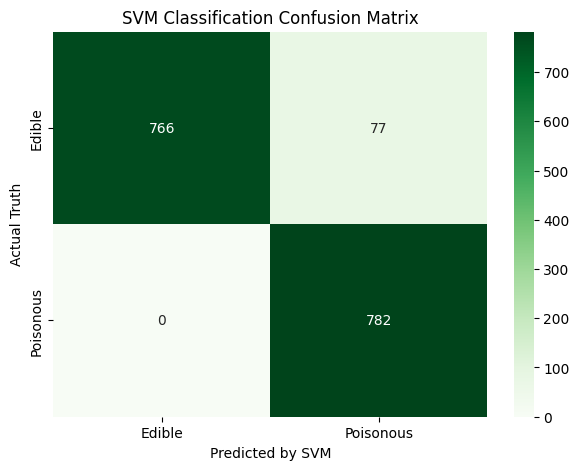

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(cm_svm_new, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted by SVM')
plt.ylabel('Actual Truth')
plt.title('SVM Classification Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test_new_svm, y_pred_new_svm_final,
                            target_names=['Edible', 'Poisonous']))

              precision    recall  f1-score   support

      Edible       1.00      0.91      0.95       843
   Poisonous       0.91      1.00      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.96      0.95      0.95      1625



# CHECK FOR SUPPOER VECTORS

In [ ]:
features_viz = ['odor', 'spore-print-color', 'gill-color', 'ring-type', 'stalk-surface-above-ring']

In [ ]:
y_viz = LabelEncoder().fit_transform(df['class'])
X_encoded_viz = pd.get_dummies(df[features_viz], dtype=int)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded_viz)

In [ ]:
svm_viz = SVC(kernel='linear', random_state=42)
svm_viz.fit(X_pca, y_viz)

SVC(kernel='linear', random_state=42)

In [ ]:
# Create a Mesh Grid to draw the decision boundary
h = .02  # step size in the mesh
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [ ]:
# Predict across the entire mesh grid
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

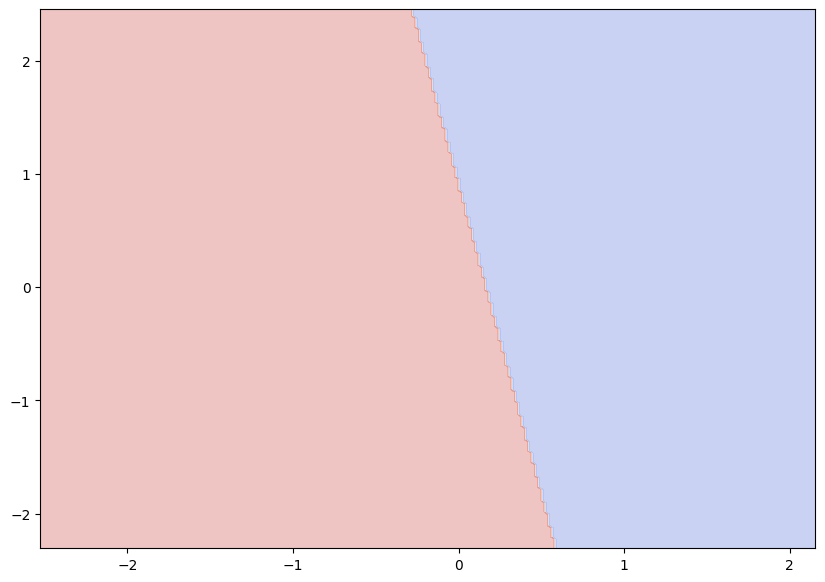

In [ ]:
# Plotting
plt.figure(figsize=(10, 7))
# Draw the decision boundary (the "Hyperplane" area)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

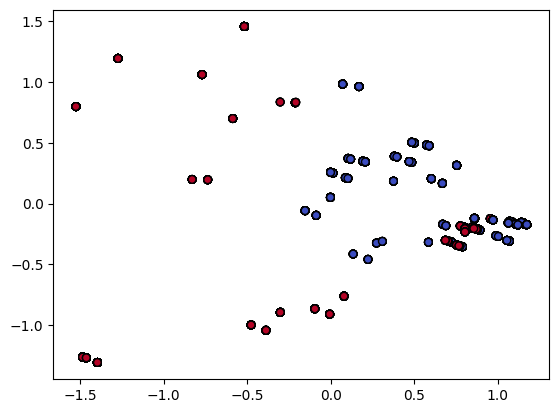

In [ ]:
# Plot the individual mushrooms (Red=Poisonous, Blue=Edible)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_viz, cmap=plt.cm.coolwarm, edgecolors='k', s=30)

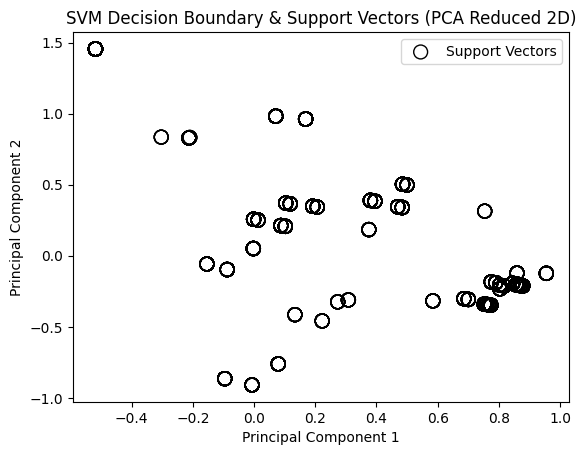

In [ ]:
# CIRCLE THE SUPPORT VECTORS
plt.scatter(svm_viz.support_vectors_[:, 0], svm_viz.support_vectors_[:, 1], s=100,
            linewidth=1, facecolors='none', edgecolors='black', label='Support Vectors')

plt.title('SVM Decision Boundary & Support Vectors (PCA Reduced 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [ ]:
print(f"Number of Support Vectors found: {len(svm_viz.support_vectors_)}")

Number of Support Vectors found: 2236
